<a href="https://colab.research.google.com/github/AiHuzaifa/Regularization_CrossVal_Hyperparameters/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# THE ULTIMATE GUIDE TO REGULARIZATION

### How to stop your AI from memorizing noise and losing its mind

For a deeper dive into these concepts, you can check out this detailed guide on [Regularization in Machine Learning](https://medium.com).

---

## PART 1: THERE ARE NO HIGHWAYS HERE (The Big Weight Misunderstanding)

When you are starting out, you will constantly hear developers say:

**"We need to penalize high weights to fix overfitting."**

Let's clear this up on day one: **There are no actual driving highways here.**

- **"High Weights"** simply means **"Numbers that are too big."**

### The Core Intuition: The Overreacting Model

Think of internal weights as how much **importance** or **leverage** your AI gives to a specific feature. If your model has massive weights, it can become hyper-sensitive, erratic, and overreact to noise.

- **The Tape Recorder Model (Huge Weights):**

  Imagine predicting house prices. Your model notices one house with a red door sold for an extra $100,000.

  Without constraints, it assigns a massive weight to door color:

  $$\text{Price} = \text{Base Price} + 100000 \times \text{Red Door}$$

  It memorized a random fluke. It has perfectly **overfit** the training data, but it will fail miserably on new, unseen data (Validation Data).

- **The Stable Model (Small Weights):**

  By encouraging weights to stay small, the model is less likely to react excessively to random patterns. It can focus more on broader relationships and become more robust when making predictions on brand-new data.

**Important:** Small weights do not automatically guarantee a good model. The model must still learn meaningful relationships from the data.

---

## PART 2: THE TRUTH ABOUT LOSS = 0 (The Mystery Box)

**"Our ultimate goal is to get our error down to zero, right?"**

**Not necessarily!**

A Training Loss of exactly `0.0000` is not automatically a victory. It can be a warning sign, especially when the model performs poorly on unseen data.

A training loss of zero can represent two very different situations:

1. **Scenario A (Genius Model):**

   Your AI discovered the underlying relationship in the data and can generalize perfectly to unseen examples.

   (This is possible, but uncommon with noisy real-world datasets.)

2. **Scenario B (Overfitting Trap):**

   Your AI cheated by acting like a tape recorder. It memorized the exact answers to its practice sheet, including random noise and unusual patterns.

### How to Detect Overfitting

You cannot reliably identify overfitting by looking at training data alone.

You must evaluate the model on data it did not train on.

Here is an example:

- **OVERFITTING EXAMPLE:**

  - `Training Loss = 0.0000` (Perfect)
  - `Validation Loss = 20.2840` (Very High)

  **Verdict:** The model memorized the practice sheet but completely failed the real exam.

- **GENUINE GENERALIZATION EXAMPLE:**

  - `Training Loss = 0.2308` (Small Error)
  - `Validation Loss = 0.8120` (Reasonably Low Error)

  **Verdict:** The model learned useful patterns and performs reasonably well on unseen data.

> **GOLDEN RULE TO REMEMBER:**
>
> Overfitting is not defined by a low training score alone. It is identified by a significant difference between training performance and validation performance, particularly when validation performance is poor.

### Understanding Training Loss vs Validation Loss

- **Training Loss:** Measures how well your model performs on the data it learned from.
- **Validation Loss:** Measures how well your model performs on separate data that it did not train on.

### What Does an Overfitting Graph Look Like?

During training:

- Training Loss generally decreases.
- Validation Loss initially decreases.
- After a certain point, Validation Loss may start increasing while Training Loss continues decreasing.

That increasing validation loss is a common sign of overfitting.

---

## PART 3: THE TECHNICAL TRICK (The Math Behind the Penalty)

How do we physically encourage a machine learning algorithm to shrink its own numbers?

We change the rules of the game using basic addition.

Normally, an AI is programmed to play a game where it tries to get the lowest possible **Total Cost** score.

### 1. Standard Linear Regression (No Penalty)

The objective function is:

$$
\text{Total Cost} = \text{Loss (Prediction Error)}
$$

Suppose the model uses a massive weight like 33 to match the training data.

Its prediction error might be zero.

$$
\text{Total Cost} = 0
$$

The computer thinks:

*"Awesome, I win!"*

But it might have overfit the training data.

### 2. Regularized Regression (With Penalty)

We rewrite the mathematical rulebook.

We tell the AI:

*"Your score is now your prediction error PLUS a penalty based on how big your weights are."*

$$
\text{Total Cost} = \text{Loss (Prediction Error)} + \text{Penalty Term}
$$

Now look at what happens technically behind the scenes.

For simplicity, let's use an L1 penalty, where the penalty is the absolute value of the weight.

**Option A: Large Weight**

- Weight = 33
- Prediction Error = 0
- Penalty = 33

$$
\text{Total Cost} = 0 + 33 = 33
$$

**Option B: Smaller Weight**

- Weight = 2
- Prediction Error = 1
- Penalty = 2

$$
\text{Total Cost} = 1 + 2 = 3
$$

Because **3 is much lower than 33**, the optimization algorithm prefers the smaller weight in this simplified example.

The model is encouraged to balance prediction accuracy with smaller weights.

**Important:** In actual machine learning, the penalty is multiplied by a regularization parameter (alpha), and the model optimizes all weights together. These numbers are just an illustration of the concept.

---

## PART 4: WHAT IS LAMBDA (λ) OR ALPHA (α)?

Think of $\lambda$ (called `alpha` in Python libraries like Scikit-Learn) as the **Volume Knob for your penalty**.

The general regularized objective function is:

$$
\text{Total Cost} = \text{Loss} + \alpha \times \text{Penalty}
$$

You choose this number before training.

It allows you to control exactly how strongly the model is penalized for having large weights.

- **$\alpha = 0$ (Turned Off):**

  The penalty disappears completely.

  The model is free to learn without regularization and may overfit if the dataset encourages it.

- **$\alpha = 1000$ (Max Volume):**

  The penalty becomes extremely strong (depending on the dataset and loss scale).

  The AI is heavily discouraged from using large weights. The model may become too simple and fail to learn important relationships.

  This is called **Underfitting**.

- **$\alpha = 1.0 \rightarrow 45.0$ (Possible Sweet Spot):**

  These are example values, not universal optimal values.

  A suitable alpha balances prediction accuracy with model complexity.

  The best value depends on your dataset, feature scaling, and model.

### What Happens When Alpha Changes?

| Alpha Value | Regularization Strength | Possible Result |
|---|---|---|
| 0 | None | Higher risk of overfitting |
| Small | Weak | Slightly smaller weights |
| Moderate | Balanced | Potentially better generalization |
| Very Large | Strong | Higher risk of underfitting |

**Remember:** You should experiment with different alpha values using cross-validation rather than randomly selecting one.

---

## PART 5: CHOOSE YOUR FIGHTER — L1 (LASSO) VS L2 (RIDGE)

There are two primary ways to calculate the mathematical penalty term.

They treat your weights differently.

### 1. Ridge Regularization (L2 Penalty)

- **The Formula:** Adds the squared magnitude of the weights.

$$
\boxed{
J(w) = \text{Loss} + \alpha \sum_{j=1}^{n} w_j^2
}
$$

Where:

- $J(w)$ = Total objective function.
- $\text{Loss}$ = Prediction error.
- $\alpha$ = Regularization strength.
- $w_j$ = Weight of the j-th feature.
- $n$ = Total number of features.

**How it behaves:**

Ridge smoothly shrinks all weights closer to zero.

It generally keeps every feature in the model but reduces the influence of features with large weights.

It usually does not make weights exactly zero.

**Think of Ridge as a weight controller:** It reduces the influence of features without completely removing them.

### 2. Lasso Regularization (L1 Penalty)

- **The Formula:** Adds the absolute value of the weights.

$$
\boxed{
J(w) = \text{Loss} + \alpha \sum_{j=1}^{n} |w_j|
}
$$

Where:

- $J(w)$ = Total objective function.
- $\text{Loss}$ = Prediction error.
- $\alpha$ = Regularization strength.
- $w_j$ = Weight of the j-th feature.
- $n$ = Total number of features.

**How it behaves:**

Lasso is the ultimate feature filter.

If you have 100 features but many of them are useless or contribute very little, Lasso can drive some of their weights **EXACTLY to 0.0000**.

When a feature's weight becomes zero, that feature is effectively removed from the model's predictions.

This is called **Feature Selection**.

**Think of Lasso as a feature selector:** It can completely eliminate unnecessary features.

### Ridge vs Lasso: Quick Comparison

| Feature | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | Squared weights | Absolute weights |
| Weight reduction | Shrinks weights | Shrinks weights |
| Exact zero weights | Usually No | Yes |
| Feature Selection | No automatic elimination | Yes |
| Best suited for | Keeping all useful features | Removing less useful features |
| Correlated features | Often distributes weights | May select one or a few |

---

## PART 6: ELASTIC NET (THE BEST OF BOTH WORLDS)

What if you want the advantages of both Ridge and Lasso?

This is where **Elastic Net** comes in.

Elastic Net combines L1 and L2 regularization.

### The Formula

$$
\boxed{
J(w) =
\text{Loss}
+
\alpha \left[
r \sum_{j=1}^{n}|w_j|
+
\frac{1-r}{2}\sum_{j=1}^{n}w_j^2
\right]
}
$$

Where:

- $\alpha$ = Overall regularization strength.
- $r$ = L1 ratio (controls the balance between Lasso and Ridge).
- $w_j$ = Weight of the j-th feature.
- $n$ = Number of features.

### How Does It Work?

Elastic Net combines:

- **L1 (Lasso):** Can drive some weights exactly to zero.
- **L2 (Ridge):** Smoothly reduces large weights.

This gives us both weight reduction and feature selection.

### Understanding the L1 Ratio

| L1 Ratio | Behavior |
|---|---|
| 0 | Pure Ridge-style penalty |
| 0.5 | Combination of Ridge and Lasso |
| 1 | Pure Lasso-style penalty |

**When should you use Elastic Net?**

When your dataset contains many features, especially when several features are highly correlated, Elastic Net can be a useful alternative to using Lasso or Ridge alone.

---

## PART 7: WHY FEATURE SCALING IS IMPORTANT BEFORE REGULARIZATION

This is a very important concept that beginners often miss.

Imagine you are predicting house prices using two features:

- House Size: 1,500 square feet.
- Number of Bedrooms: 3.

Their numerical scales are very different.

A regularization algorithm penalizes weights, not the original feature values.

Because features have different scales, their weights may naturally have different magnitudes.

This can cause regularization to penalize features unfairly.

### The Solution: Standardization

We commonly use StandardScaler to bring features onto a comparable scale.

The formula is:

$$
\boxed{
z = \frac{x-\mu}{\sigma}
}
$$

Where:

- $x$ = Original feature value.
- $\mu$ = Mean of the feature.
- $\sigma$ = Standard deviation.
- $z$ = Standardized feature value.

After standardization:

- Mean is approximately 0.
- Standard deviation is approximately 1.

### Python Example

```python
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# Create a pipeline
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)
```

**Important:** Always fit the scaler on training data only. The pipeline handles this automatically during training and prevents information leakage from the test data.

---

## PART 8: THE BIAS-VARIANCE TRADE-OFF

Regularization is closely connected to something called the **Bias-Variance Trade-off**.

To understand it, remember:

- **Bias:** Error caused by a model being too simple to capture the actual patterns in the data.
- **Variance:** Error caused by a model being too sensitive to small changes or random noise in the training data.

### Understanding the Relationship

| Situation | Bias | Variance | Result |
|---|---|---|---|
| Model too simple | High | Low | Underfitting |
| Model too complex | Low | High | Overfitting |
| Well-balanced model | Reasonable | Reasonable | Better generalization |

### How Regularization Helps

When we increase regularization:

- Model complexity generally decreases.
- Variance generally decreases.
- Bias generally increases.

The objective is to find a balance where the model performs well on unseen data.

**Golden Rule:** Too little regularization can lead to overfitting, while too much regularization can lead to underfitting.

---

## PART 9: HOW TO SELECT THE BEST ALPHA IN PYTHON

You do not have to guess the best alpha value.

Scikit-Learn provides tools such as GridSearchCV that allow you to test multiple values using cross-validation.

### Python Example: Ridge Regression

```python
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Create a pipeline
pipeline = make_pipeline(
    StandardScaler(),
    Ridge()
)

# Define alpha values
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Perform cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Train and evaluate
grid_search.fit(X_train, y_train)

# Display the best alpha
print("Best Alpha:", grid_search.best_params_)

# Display the best cross-validation score
print("Best CV Score:", grid_search.best_score_)

# Evaluate on test data
best_model = grid_search.best_estimator_

print("Test Score:", best_model.score(X_test, y_test))
```

**What is happening here?**

1. We define multiple alpha values.
2. GridSearchCV tests each value.
3. It performs 5-fold cross-validation.
4. It identifies the alpha with the best average validation performance.
5. We evaluate the selected model on the test dataset.

**Important:** Keep the test dataset separate until the final evaluation. Do not repeatedly use it to select hyperparameters.

---

## QUICK SUMMARY CHEAT SHEET FOR BEGINNERS

1. **Overfitting** means your model has learned the training data too closely, including noise, instead of learning patterns that generalize well.

2. Check your plots! Look for the moment your **Validation Loss** starts climbing while **Training Loss** continues decreasing.

3. Do not panic when a small gap remains between your Training and Validation scores after fixing overfitting. That is completely normal.

4. Use **Ridge (L2)** when you want to keep your features but make their weights more stable.

5. Use **Lasso (L1)** when you want automatic feature selection and want some weights to become exactly zero.

6. Use **Elastic Net** when you want a combination of Ridge and Lasso.

7. Always consider **Feature Scaling** before applying regularization because features with different scales can affect the penalty unfairly.

8. Use **Cross-Validation** to find a suitable alpha instead of randomly choosing a value.

9. Remember the **Bias-Variance Trade-off**: Too little regularization can cause overfitting, while too much can cause underfitting.

---

## THE FINAL CONCEPT TO REMEMBER

Regularization does not teach an AI to memorize better.

It encourages the AI to learn simpler, more stable relationships instead of relying too heavily on individual features.

The ultimate objective is not to achieve zero training error.

The ultimate objective is:

$$
\boxed{
\text{Good Training Performance}
+
\text{Good Validation Performance}
=
\text{Better Generalization}
}
$$

**A smart model is not the one that remembers everything. It is the one that understands the pattern well enough to make good predictions on something it has never seen before.**

--- LINEAR REGRESSION RESULTS ---
Training Loss: 0.0000  (Overfitting completely!)
Validation Loss: 20.2840 (Explodes because it trusted the noise)
--- LINEAR REGRESSION RESULTS ---
Training Loss: 0.0000 (Perfect 0 -> Overfitting!)
Validation Loss: 20.2840 (Massive error on unseen data)



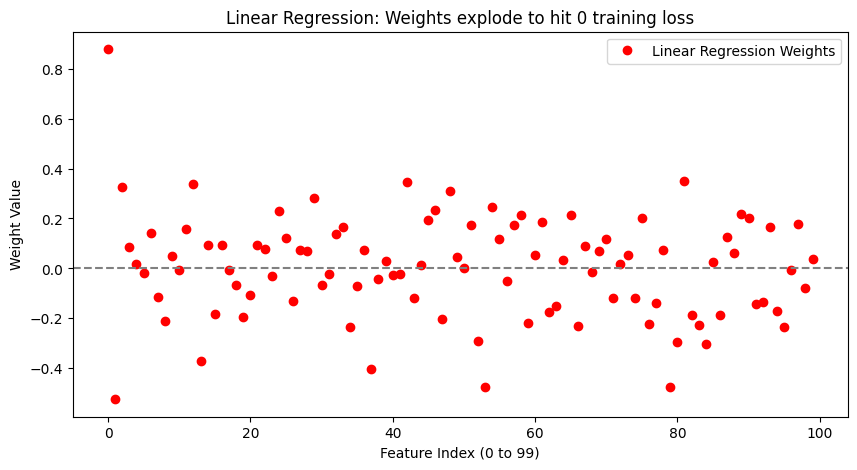

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# 1. Create a dataset with a REAL underlying linear signal + random noise
np.random.seed(42)
X = np.random.randn(30, 100) # 30 rows, 100 features

# The true formula only relies on the first two features, the rest 98 are trash noise!
y = 3 * X[:, 0] - 2 * X[:, 1] + np.random.normal(0, 1.5, size=30)

# 2. Split into Train and Validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# ==========================================
# STEP 3: STANDARD LINEAR REGRESSION (No Penalty)
# ==========================================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

lin_train_loss = mean_squared_error(y_train, linear_model.predict(X_train))
lin_val_loss = mean_squared_error(y_val, linear_model.predict(X_val))

print("--- LINEAR REGRESSION RESULTS ---")
print(f"Training Loss: {lin_train_loss:.4f}  (Overfitting completely!)")
print(f"Validation Loss: {lin_val_loss:.4f} (Explodes because it trusted the noise)")

# ==========================================
# RUN BASIC LINEAR REGRESSION
# ==========================================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Calculate Losses
lin_train_loss = mean_squared_error(y_train, linear_model.predict(X_train))
lin_val_loss = mean_squared_error(y_val, linear_model.predict(X_val))

print("--- LINEAR REGRESSION RESULTS ---")
print(f"Training Loss: {lin_train_loss:.4f} (Perfect 0 -> Overfitting!)")
print(f"Validation Loss: {lin_val_loss:.4f} (Massive error on unseen data)\n")

# Plot the wild weights
plt.figure(figsize=(10, 5))
plt.plot(linear_model.coef_, color='red', marker='o', linestyle='None', label='Linear Regression Weights')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Linear Regression: Weights explode to hit 0 training loss")
plt.xlabel("Feature Index (0 to 99)")
plt.ylabel("Weight Value")
plt.legend()
plt.show()


--- RIDGE REGULARIZATION RESULTS ---
Training Loss: 2.6011 (Gave up a little perfection)
Validation Loss: 17.3487 (Fixed! Error dropped drastically)



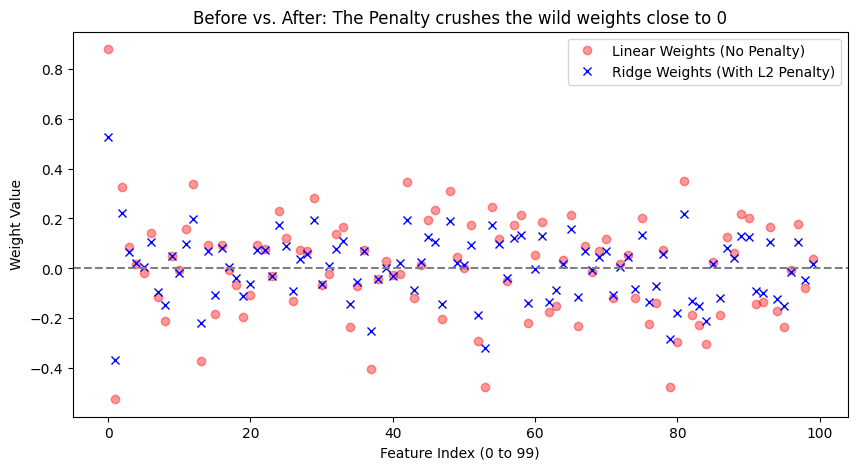

In [12]:
# ==========================================
# RUN RIDGE REGULARIZATION (L2 Penalty)
# ==========================================
# alpha=10 means we are turning the penalty volume knob up high
ridge_model = Ridge(alpha=48)
ridge_model.fit(X_train, y_train)

# Calculate Losses
ridge_train_loss = mean_squared_error(y_train, ridge_model.predict(X_train))
ridge_val_loss = mean_squared_error(y_val, ridge_model.predict(X_val))

print("--- RIDGE REGULARIZATION RESULTS ---")
print(f"Training Loss: {ridge_train_loss:.4f} (Gave up a little perfection)")
print(f"Validation Loss: {ridge_val_loss:.4f} (Fixed! Error dropped drastically)\n")

# Plot both together to clearly see the contrast
plt.figure(figsize=(10, 5))
plt.plot(linear_model.coef_, color='red', marker='o', linestyle='None', alpha=0.4, label='Linear Weights (No Penalty)')
plt.plot(ridge_model.coef_, color='blue', marker='x', linestyle='None', alpha=1.0, label='Ridge Weights (With L2 Penalty)')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Before vs. After: The Penalty crushes the wild weights close to 0")
plt.xlabel("Feature Index (0 to 99)")
plt.ylabel("Weight Value")
plt.legend()
plt.show()


--- LASSO (L1) REGULARIZATION RESULTS ---
Training Loss: 0.0678
Validation Loss: 7.2434
Lasso completely deleted 85 out of 100 features!



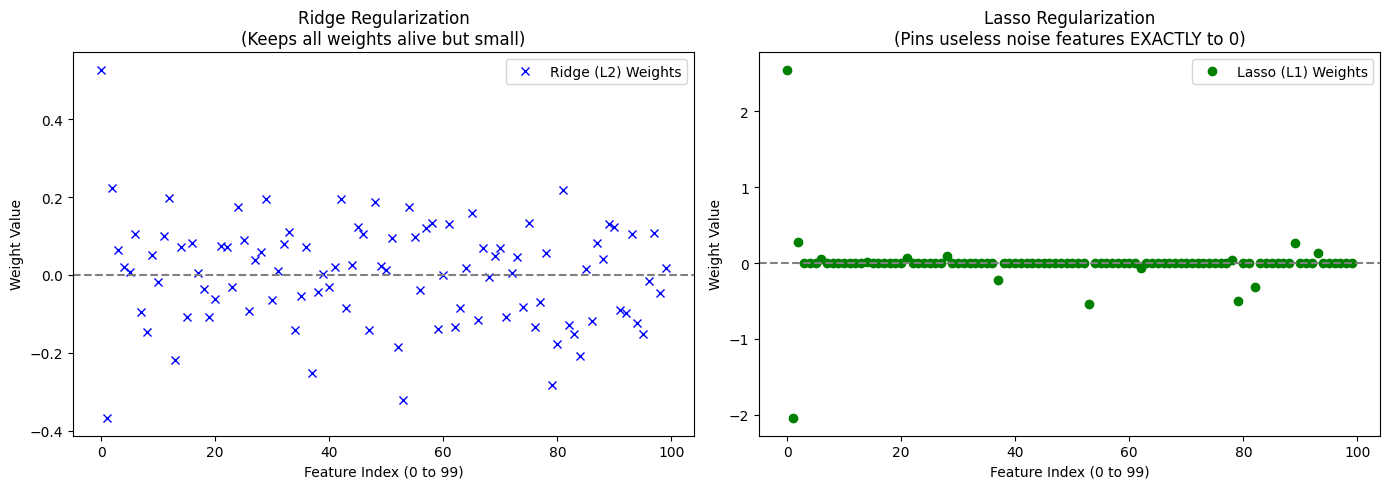

In [18]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

lasso_train_loss = mean_squared_error(y_train, lasso_model.predict(X_train))
lasso_val_loss = mean_squared_error(y_val, lasso_model.predict(X_val))

print("--- LASSO (L1) REGULARIZATION RESULTS ---")
print(f"Training Loss: {lasso_train_loss:.4f}")
print(f"Validation Loss: {lasso_val_loss:.4f}")

# Count how many features Lasso turned off
zeroed_weights = np.sum(lasso_model.coef_ == 0)
print(f"Lasso completely deleted {zeroed_weights} out of 100 features!\n")

# ==========================================
# VISUALIZE RIDGE VS LASSO WEIGHTS
# ==========================================
plt.figure(figsize=(14, 5))

# Plot 1: Your best Ridge weights (alpha=45)
plt.subplot(1, 2, 1)
plt.plot(ridge_model.coef_, color='blue', marker='x', linestyle='None', label='Ridge (L2) Weights')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Ridge Regularization\n(Keeps all weights alive but small)")
plt.xlabel("Feature Index (0 to 99)")
plt.ylabel("Weight Value")
plt.legend()

# Plot 2: New Lasso weights (alpha=0.1)
plt.subplot(1, 2, 2)
plt.plot(lasso_model.coef_, color='green', marker='o', linestyle='None', label='Lasso (L1) Weights')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Lasso Regularization\n(Pins useless noise features EXACTLY to 0)")
plt.xlabel("Feature Index (0 to 99)")
plt.ylabel("Weight Value")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y.shape

(569,)